<a href="https://colab.research.google.com/github/ismummottammim/problem_2_bank/blob/main/problem_2_bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install and Import Libraries
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# =============================================
# UPLOAD AND LOAD REAL DATASET
# =============================================
from google.colab import files
print("  By: Ismum Mottammim")
print("📂 Please upload your 'bank-full.csv' file...")
uploaded = files.upload()

# Get filename and load the file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, sep=';')

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")
df.head()

  By: Ismum Mottammim
📂 Please upload your 'bank-full.csv' file...


In [ ]:
print("="*70)
print("STEP 1: EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\nTarget Variable Distribution:")
print(df['y'].value_counts())
print(f"\nPercentage of 'Yes': {(df['y']=='yes').mean()*100:.2f}%")

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('y')

print(f"\nNumerical Features: {len(numerical_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")

STEP 1: EXPLORATORY DATA ANALYSIS

Target Variable Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage of 'Yes': 11.70%

Numerical Features: 7
Categorical Features: 9


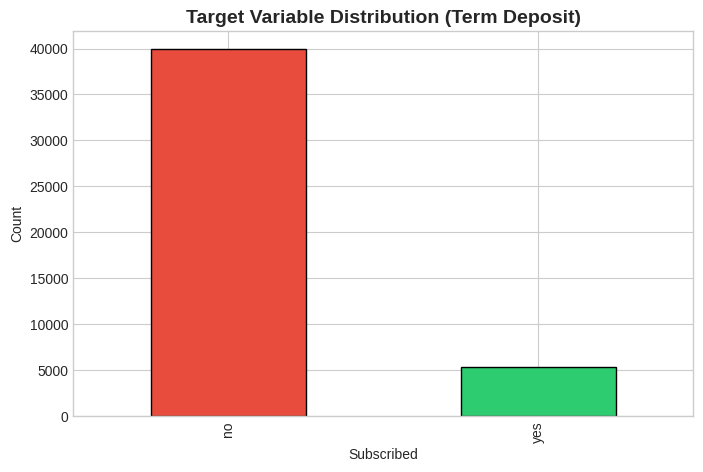

In [ ]:
colors = ['#e74c3c', '#2ecc71']

# Target Distribution
plt.figure(figsize=(8,5))
df['y'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Target Variable Distribution (Term Deposit)', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.show()

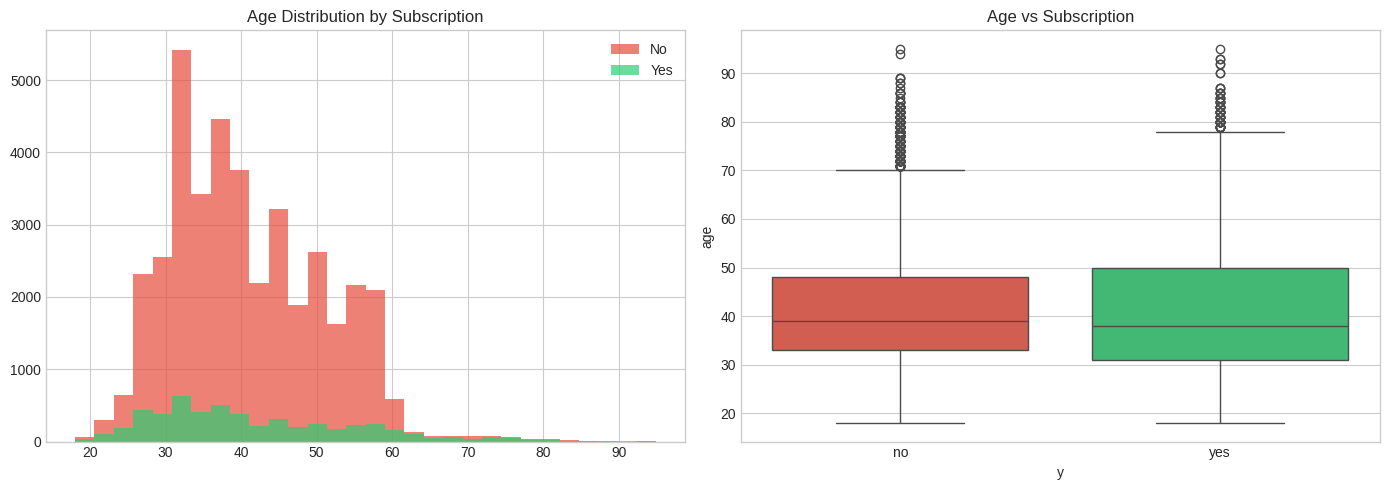

In [ ]:
# Age vs Subscription
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df[df['y']=='no']['age'].hist(bins=30, alpha=0.7, color='#e74c3c', ax=axes[0], label='No')
df[df['y']=='yes']['age'].hist(bins=30, alpha=0.7, color='#2ecc71', ax=axes[0], label='Yes')
axes[0].set_title('Age Distribution by Subscription')
axes[0].legend()

sns.boxplot(x='y', y='age', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Age vs Subscription')
plt.tight_layout()
plt.show()

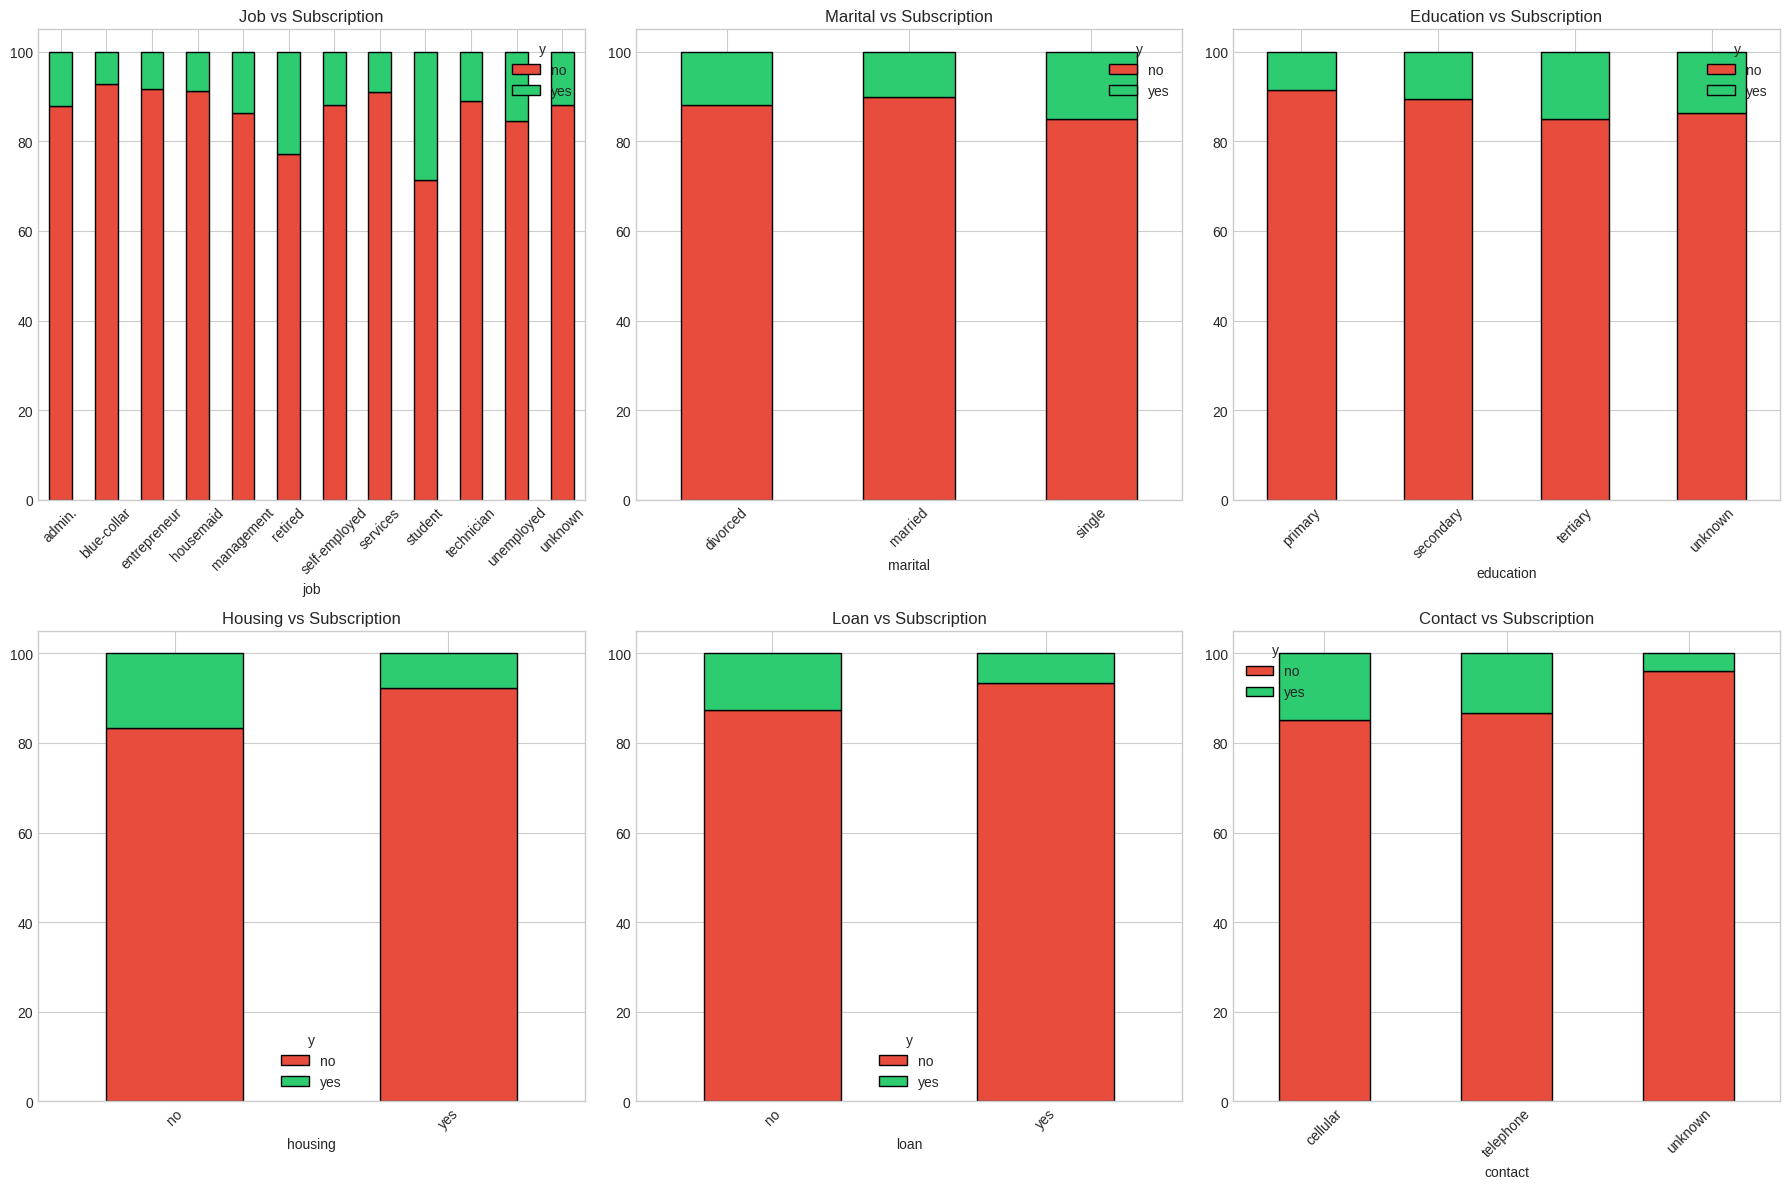

In [ ]:
# Categorical Features vs Target
fig, axes = plt.subplots(2, 3, figsize=(18,12))
cat_plot = ['job', 'marital', 'education', 'housing', 'loan', 'contact']
for i, col in enumerate(cat_plot):
    ax = axes[i//3, i%3]
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=colors, ax=ax, edgecolor='black')
    ax.set_title(f'{col.title()} vs Subscription')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("STEP 2: DATA PREPROCESSING")
print("="*70)

data = df.copy()

# Encode target
data['y'] = data['y'].map({'yes': 1, 'no': 0})

# Label Encoding for categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split features and target
X = data.drop('y', axis=1)
y = data['y']

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("✅ Preprocessing completed!")
print(f"Final feature shape: {X_scaled.shape}")

STEP 2: DATA PREPROCESSING
✅ Preprocessing completed!
Final feature shape: (45211, 16)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Logistic Regression Model
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
print("✅ Logistic Regression Model trained successfully!")

Training samples: 36168
Testing samples:  9043
✅ Logistic Regression Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

MODEL PERFORMANCE
Accuracy  : 0.8094 (80.94%)
Precision : 0.3590
Recall    : 0.8015
F1 Score  : 0.4959
ROC AUC   : 0.8762

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.81      0.88      7985
         Yes       0.36      0.80      0.50      1058

    accuracy                           0.81      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.90      0.81      0.84      9043



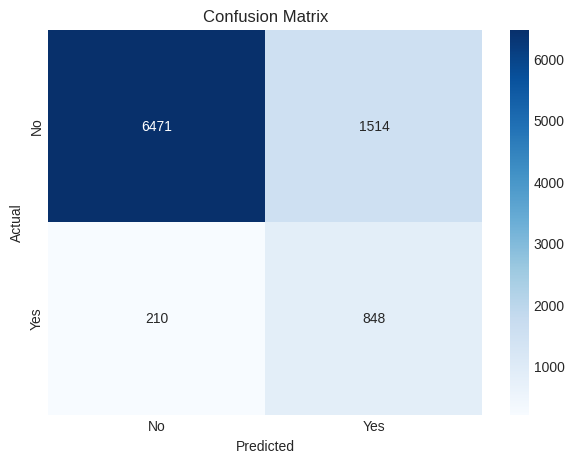

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

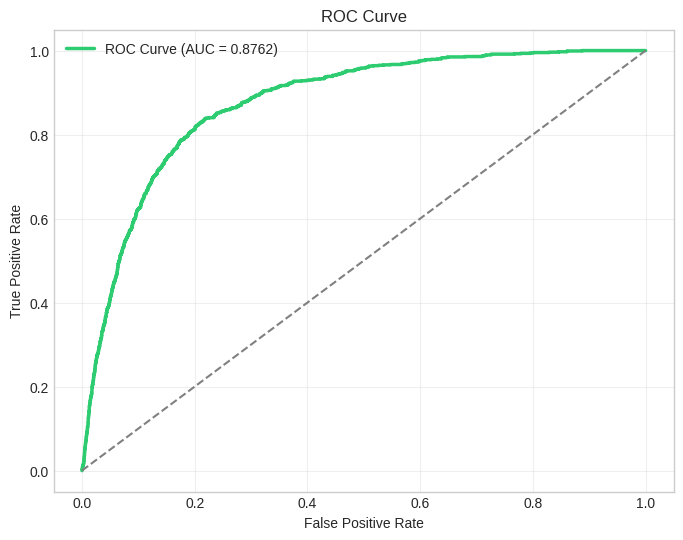

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Top 10 Most Important Features:
      Feature  Coefficient
11   duration     1.385635
13      pdays     0.355348
14   previous     0.344423
15   poutcome     0.246193
3   education     0.176092
2     marital     0.149295
10      month     0.097413
0         age     0.093007
5     balance     0.092951
1         job     0.029479


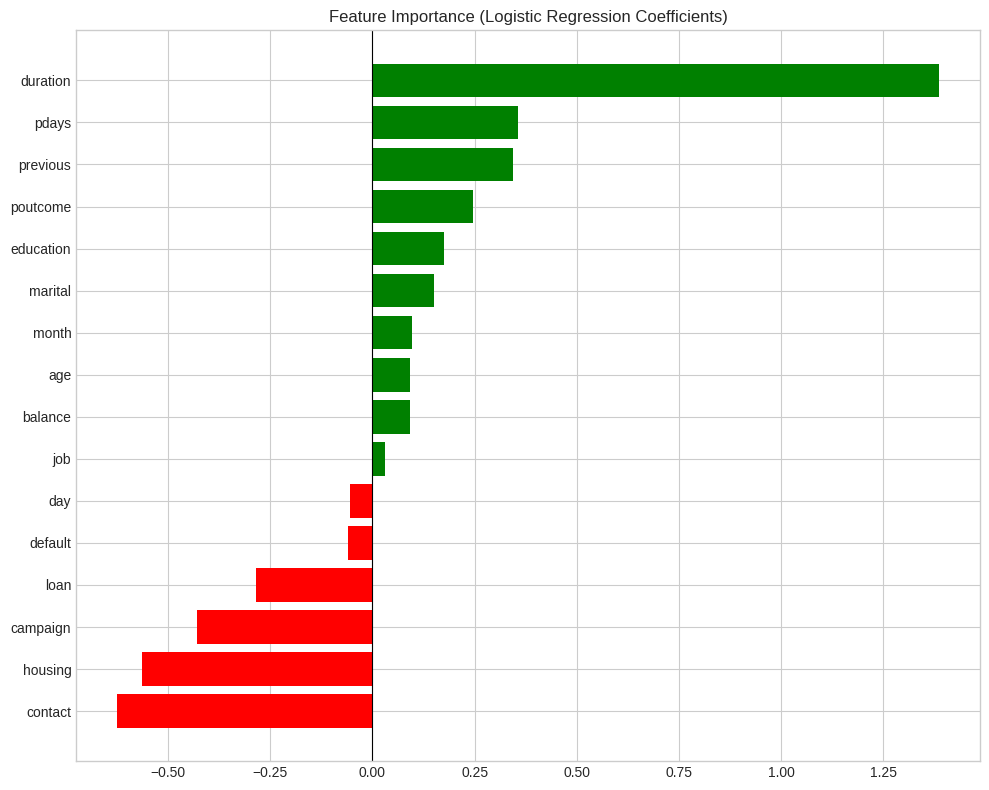

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 Most Important Features:")
print(coef_df.head(10))

# Plot Feature Importance
plt.figure(figsize=(10,8))
coef_sorted = coef_df.sort_values('Coefficient')
colors_coef = ['red' if c < 0 else 'green' for c in coef_sorted['Coefficient']]
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_coef)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("FINAL SUMMARY - PROBLEM SET 02")
print("="*70)
print(f"""
Model Used          : Logistic Regression
Dataset             : Bank Marketing (bank-full.csv)
Total Samples       : {df.shape[0]}
Features Used       : {X.shape[1]}
Test Accuracy       : {accuracy*100:.2f}%
ROC AUC Score       : {roc_auc:.4f}
Class Weight        : Balanced (to handle imbalance)


""")


FINAL SUMMARY - PROBLEM SET 02

Model Used          : Logistic Regression
Dataset             : Bank Marketing (bank-full.csv)
Total Samples       : 45211
Features Used       : 16
Test Accuracy       : 80.94%
ROC AUC Score       : 0.8762
Class Weight        : Balanced (to handle imbalance)



